# Solving PDE with Tensor Network

## 1. Define a PDE problem 

As an example we will try out the following PDE of 1D (our code up until before DMRG section works will any nD PDE) scalar function $u = u(t, x)$,

$\dfrac{\partial}{\partial t}u = 5xu + \dfrac{\partial}{\partial x}u$

with initial condition $u(0, x) = x$ and boundary condition $u(t, 0) = 0$. Also, consider the simulation in the range $x\in [0, 1]$ and $t\in [0, 1]$. We'll first parse this problem in to a machine readable format. Observe the following code. We will only consider a PDE with linear time derivatives (LT-PDE), i.e., any PDE that can be written with simply $\dfrac{\partial}{\partial t}u$ on the LHS, and the RHS contain no time derivative. Hence, we will only write down the RHS to the `pde_txt` with the following construction rules.
1. Any implicit multiplication must make explicit with `*`.
2. The coordinates in the derivatives $x$, $y$, $z$, ... are represented as `0`, `1`, `2`, ...
3. $\dfrac{\partial}{\partial v}x$ is represented with `D[1, 0]` with the first argument be the differential order and the subsequence arguments specify the axes of differentiations.
4. Any subtraction must be written as addition with $(-1)$ multiply by the subtracting term
5. No division.
6. Any function that is not $u$ or constant would be represented in as list of functions `hs`, e.g., if the PDE is $\dfrac{\partial}{\partial t}u = xu + x^2\dfrac{\partial}{\partial x}u$, then $x$, and $x^2$ will be replaced with `h_0`, and `h_1` both contained in `hs`, i.e., `pde_txt = 'h_1*u+h_2*D[1, 0]'`

In [1]:
pde_txt = '5*h_0*u+D[1, 0]'

Next, we will call our PDE parser class to read, simplify and restructure `pde_txt`.

In [2]:
from utils.pde import PDE

pde = PDE(pde_txt)

Then, we can check out the parsed PDE as followed.

In [3]:
pde.pde

['+', ['*', ['h', 0], 'u', 5.0], ['D', 1.0, 0.0]]

We'll postpone the detail for depicting each `hs`, initial conditions, and boundary conditions after we setting up the finite element (FE) structure.

## 2. Domain triangulation and standard basis

Next, with `Triangulation` class, we can populate the spatial domain with points to partition the domains into smaller elements. The following code will show the code for 2D unit square domain for visualization before going back to our problem 1D unit segment domain. The 2D case use random point sampling while 1D use perturbed uniform grid, both contain extra points to secure the domain corners. As an emperical rule of thumb, the required number of `n_internal_points` grows exponentially with `d`.

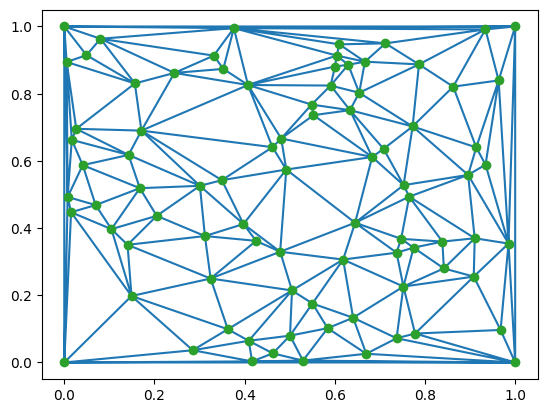

In [4]:
import numpy as np
from utils.triangulation import Triangulation

d_2D = 2
n_internal_points_2D = 81

points_2D = np.concatenate([np.random.random((n_internal_points_2D, d_2D)), 
                         np.array(list(zip(*[coordinate.flatten() for coordinate in np.meshgrid(*([[0, 1]] * d_2D))])))], 
                         axis = 0)

triangulation_2D = Triangulation(points_2D)
triangulation_2D.visualize()

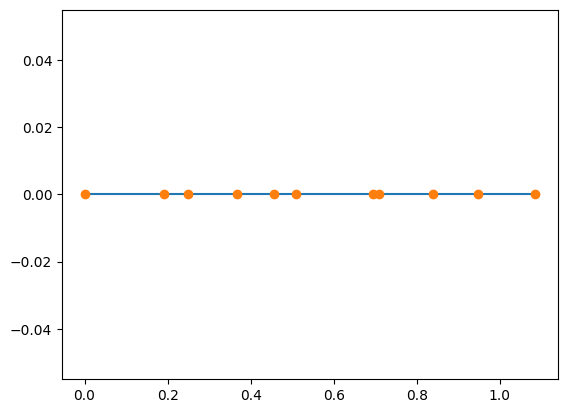

In [5]:
d = 1
n_internal_points = 9

points = np.linspace(0, 1, n_internal_points + 2)
perturbation = 0.1 * np.random.random(n_internal_points + 2)
perturbation[0] = 0
perturbation[-11] = 0
points += perturbation

triangulation = Triangulation(points)
triangulation.visualize()

For 2D case, this is not quite a good set of sampling points. We need more points on the edges to capture the boundary conditions that might come up but user can design and experiment with that.

The next step is to prepare the standard bases of each triangulation unit. Here, we will use simplex triangulation type, e.g., segment for 1D, triangle for 2D, tetrahedral for 3D, etc. The standard means that we will work with simplices with corners at origin and unit Cartesian basis vectors, e.g., $\{(0,), (1,)\}$ for 1D, $\{(0, 0), (1, 0), (0, 1)\}$ for 2D, $\{(0, 0, 0), (1, 0, 0), (0, 1, 0), (1, 0, 0)\}$ for 3D, etc.

For this demo, we will use Lagrange polynomial basis. The following code show how to initialize bases with different polynomial orders (`domain_rank`) in 1D and 2D as well as the visualization of those bases. Note that, the call for 2D case only call the basis function for visualization not create the class object since we don't need to waste time running for basis projection, tensor product reduction, and basis derivative matrices calculations which can take a large over head for high polynomial orders. Also, the 2D visualization use `plt.imshow` which reversed the $y$ axis.

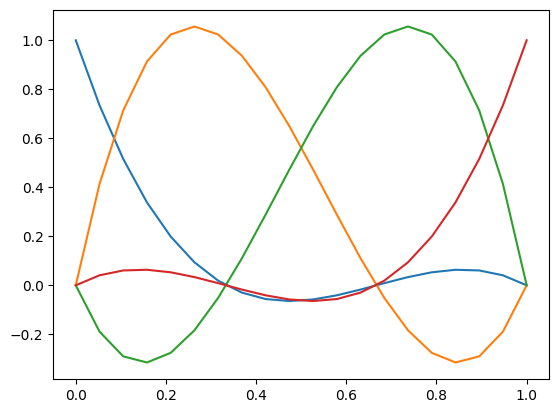

In [6]:
from utils.finite_element import LagrangeBasis

domain_rank = 3
basis = LagrangeBasis(d, domain_rank)
basis.visualize()

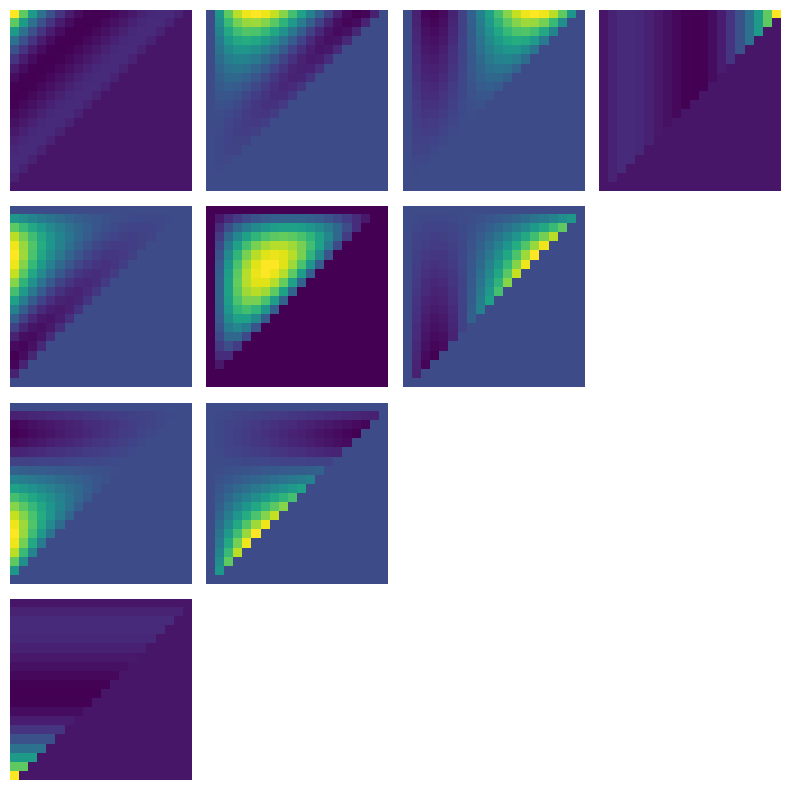

In [7]:
domain_rank_2D = 3
mock_basis_2D = LagrangeBasis(d_2D, domain_rank_2D, mock = True)
mock_basis_2D.visualize()

## 3. FE Structure

The previous part triangulate the problem domain and prepare the standard bases for standard (simplex) domains, but we need the basis that is usable for each element. Since the elements are all simplices. We can apply affine transformation to/from the standard one. One need to be extra careful when do the transformation, e.g., the drivatives transform covariantly while the velocity field transform contravariantly. The `is_contravariant` arguments on some functions is for this purpose, i.e., indicating each tensorial indices whether it is contravariant or not.The `FiniteElement` class handle this management between elements.

In [8]:
from utils.finite_element import FiniteElement

fe = FiniteElement(triangulation, basis)

One might notice, if look through the code, that `FiniteElement` treat each element independently, i.e., any interpolation will most likely discontinuous between adjacent elements for any spatial derivative order, including 0th order. This has influence from discontinuous Galekin method widely use in spectral element method (a sub-category of FEM). Here, instead of using flux correction ponalty, we will allocate the correction to the tensor network optimization as an optimization regularizer.

# 4. Boundary Conditions (BCs)

There are 2 kinds of BCs we are dealing with:
1. Element-Element BCs
2. Element-Environment BCs.

Notice that, with Lagrange polynomial basis, only 2 bases are non-zero at the edge (1D) case. Hence, if element `E_i` is on the left of element `E_j` and the bases are order with the peak positions, the continuity condition is `E_i[-1] - E_j[0] = 0`. Similarly, lets `D_i` and `D_j` represent our derivative projection matrices for `E_i` and `E_j`, respectively, then the smoothness can be enforce with `(D_i @ E_i)[-1] - (D_j @ E_j)[0] = 0`. Also, if `E_i` is on the left edge, and we want the function to be flat at the left edge, then we can use the condition `(D_i @ E_i)[0] = 0`. 

The normal way to deal with this is to write down the conditions into matrix equation, solve for particular and null-space solutions, and work on this basis projection in stead. However, the null-space will most likely not able to be independently factored for each element. Fortunately, this is what the idea of MPS can be very useful because the BCs only directly imposed on adjacent elements. Hence, on top of the main tensor network for solving PDE we will also have a parallel networks that dealt with each BCs, and we will weight sum them as our optimization criteria.

Furthermore, the interpolation of each function in `hs` also need to use this scheme instead of blindly use independent interpolation of `FiniteElement` to ensure their continuity of the interpolation. To be specific, instead of perfectly enforce the BCs exactly with null-space calculation, we will co-optimize the main objective together with the BCs, e.g., with `E_i[-1] - E_j[0] = 0` condition, we will try to minimize `(E_i[-1] - E_j[0])^2` this can be written as a variational problem of 2-node tensor network operator. For the Element-Environment BCs, we can do with 1-node tensor network operator. Furthermore, with sequencial optimization scheme like in DMRG, only a few of these BCs matter in each optimization step. One can also easily apply this idea to the higher dimension case since all BCs are between a pair of adjacent elements or an element to the envirenment. 

We wrap this function for Element-Element BCs with the highest `continuity_order`, i.e., enforce continuity upto that spatial derivatives. Note that, for higher dimensions, there are more than a pair of bases that need to be matched per BC. Hence, we need to choose a proper `domain_rank` so that the degree of freedom of the element won't completely run out. For coding purpose, the BC tensor network operator will be slightly different for the same BC but when optimizing each of the element. This is for the higher dimension case when there is multiple neighbors. The following code construct tensor network operator for the continuity up to the first differentiation. The shape of the operator should be `(n, d + 1, r + 1, r + 1, r + 1, r + 1)` where `n` is number of elements, `d + 1` is number of sides of each simplex, and `r` is basis rank. The `+ 1` to `r` comes from the tensor product trick that nake it possible to subtract the representations from different elements.

In [9]:
fe.set_con_bc_operators(1)
fe.con_bc_operators.shape

(10, 2, 5, 5, 5, 5)

Since the continuity condition can be applied to any axes of the function, we can generalize the `fe.con_bc_operators` by broadcasting to those indices. For example, if `u` is a rank 2 3D tensor:

In [10]:
fe.set_u_shape((3, 3))
fe.con_bc_operators.shape

(10, 2, 37, 37, 37, 37)

However, for this demo, `u` is a scalar function.

In [11]:
fe.set_u_shape(tuple())
fe.con_bc_operators.shape

(10, 2, 5, 5, 5, 5)

The Element-Environment BCs require a deeper preparation. The current code cannot automatically search the elements that intersect the boundaries. User need to manually provide this part. `env_bcs` is a linked dictionary with the outer layer indicate the element, and the inner indicate the side of which the element faces environment instead of other element. The BCs that govern this side (we'll assume that we place our elements such that the boundaries coincide with some elements' boundaries) can be described as `m` equations each of which is a linear combination of some derivarives of `u` that equate to some constant. In particular, each BC is a tuple of two entries. The first is a list of factors for each derivative orders from zeroth, first, second, etc. Note that for `d` dimensional problem, the `n` order derivatives has `d ** n` components. Hence, each term is an `(m, d, ..., d, r)` array where there are `n+p` number of `d`'s where the first `n` is from derivatives and the last `p` is from the shape of tensor `u` and `r` is the number of rank of the elements that expose to that side. The second is an array that is the result of those linear combination. Hence, it is an array of size `(m, d, ..., d, 1)` where there are `p` number of `d`'s. 

For our demo, the only Element-Environment BC is $u(t, 0) = 0$ which only involve the element 0 on neigher 1 side (left). The condition only has 1 equation on one rank and only has the zeroth derivative term which equate its scalar value to 0.

In [12]:
env_bcs = {0: {1: ([np.array([[1]])], np.array([[0]]))}}

After the preparation of the Element-Environment BCs information. We can construct the operator for them with the following code. The shape of the operator should be `(r + 1, r + 1)` where `r` is basis rank.

In [13]:
fe.set_env_bc_operators(env_bcs)
fe.env_bc_operators[0][1].shape

(5, 5)

# 5. Tensor Network

Now we are ready to perform the magic. There are 3 type of tensor network we need to construct:
1. BC networks
2. interpolation networks
3. main PDE network

Each of these can be handle with our `TensorNetwork` class. Note that, the main PDE network relies on the results of interpolation. Hence, we cannot construct the PDE network yet.

In [14]:
from utils.tensor_network import TensorNetwork

tn = TensorNetwork(basis.rank, triangulation.neighbors, fe.domain_derivatives_list, basis.tp_reduce)

# 6. Interpolation Subroutine

This section will show how to construct interpolation network with constrints given by BC network that will be used by the main PDE network. Looking back at the PDE 

$\dfrac{\partial}{\partial t}u = 5xu + \dfrac{\partial}{\partial x}u$,

we can see that the only interpolation task are for $x$ into our basis as well as the initial condition (which is the same function, $x$, for this example). The remaining parts are the target function, derivative of target function and the target function of the previous round, all of which are already in our basis representations. 

The main idea for the interpolation is that we use a naive independent projection by `fe` into the basis, and then we balance the square loss between our state to the projection with the loss due to the continuity conditions.

In [15]:
fun = lambda x: x
rep = fe.fun2rep(fun)
fun_rec = fe.rep2fun(rep)

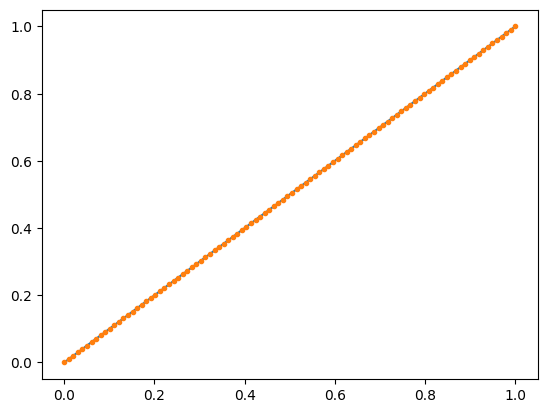

In [16]:
import matplotlib.pyplot as plt

x = np.linspace(0, 1, 100)
plt.figure()
plt.plot(x, fun(x))
plt.plot(x, [fun_rec(np.array([c])) for c in x], '.')
plt.show()

# 7. Solving PDE

The fact that we limited the problem into LT-PDE make it possible to isolate the time derivatives parts as the iterative application of tensor network optimization subroutine for the spatial derivatives. We will use the simplest form of implicit Euler method for this demo. (one can use any of the higher degree finite difference methods)

The process will be as followed:
1. Construct the main PDE, and BC networks.
2. Construct and interpolate all functions in `h_s` with interpolation and BC neteworks co-optimization. (might need to be done at every time step if the function is time dependent)
3. Construct and interpolate initial condition function.
4. Solve the main PDE for the next time step.
5. Redo step 2 if needed. (no need for this demo's PDE)
6. Redo step 4 with the solution from step 4 (of the previous round) as the new initial condition. (no need to reinterpolate since it already in the MPS format)